# ⚖️ AutoML Engine Comparison — H2O vs. FLAML vs. AutoGluon

This notebook drives Decisera's **live backend API** (`/api/v1/models/train`) once per engine — **H2O**, **FLAML**, and **AutoGluon** — on the *same* dataset/target/time budget, polls each training task to completion, and compares the resulting best models side-by-side.

Unlike `smart_city_digital_twin_training.ipynb` (which trains engines in-process inside the notebook), this notebook exercises the real request path a Decisera user goes through: upload a dataset → call `/models/train` with an engine flag → poll `/models/tasks/{task_id}/status` → read back `best_model` / `best_score` / leaderboard.

### Requirements
- A running Decisera stack (`docker compose up`) including the `backend`, `h2o`, and `autogluon` services.
- FLAML runs in-process inside the `backend` container, so no extra service is needed for it.
- If a service (e.g. `h2o` or `autogluon`) isn't running, `AutoML.fit()` logs a warning and falls back to the next engine — that run will show up below labeled with whatever engine actually served it.


## 1. Setup


In [1]:
import os
import io
import time
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

# Same BACKEND_URL convention used by the other notebooks (see smart_city_multi_inferences.ipynb):
# defaults to the docker-compose service name, override with an env var when running outside Docker
# (e.g. BACKEND_URL=http://localhost:8000 if you're on the host machine, not inside the `notebook` container).
BACKEND_URL = os.environ.get("BACKEND_URL", "http://backend:8000")
API_BASE = f"{BACKEND_URL}/api/v1"
print(f"Using Decisera backend at: {API_BASE}")


Using Decisera backend at: http://backend:8000/api/v1


## 2. Verify the backend is reachable


In [2]:
resp = requests.get(f"{BACKEND_URL}/health", timeout=5)
resp.raise_for_status()
print("Backend health:", resp.json())


Backend health: {'status': 'healthy', 'version': '1.0.1', 'timestamp': 1789670042.7215648}


## 3. Generate a benchmark dataset and upload it

A synthetic classification dataset keeps this notebook self-contained and reproducible (no Kaggle credentials needed) while still being representative tabular data for the engines to search over. Swap this cell for `pd.read_csv(...)` of your own dataset if you'd rather compare engines on real data.


In [3]:
from sklearn.datasets import make_classification

X_arr, y_arr = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    n_classes=2,
    weights=[0.7, 0.3],
    random_state=42,
)
feature_cols = [f"feature_{i}" for i in range(X_arr.shape[1])]
bench_df = pd.DataFrame(X_arr, columns=feature_cols)
bench_df["target"] = y_arr

csv_bytes = bench_df.to_csv(index=False).encode("utf-8")
dataset_name = f"automl_engine_benchmark_{int(time.time())}"

upload_resp = requests.post(
    f"{API_BASE}/datasets/upload",
    files={"file": (f"{dataset_name}.csv", io.BytesIO(csv_bytes), "text/csv")},
    data={"name": dataset_name, "description": "Synthetic benchmark dataset for AutoML engine comparison"},
    timeout=30,
)
upload_resp.raise_for_status()
dataset_id = upload_resp.json()["dataset"]["id"]
print(f"Uploaded dataset '{dataset_name}' -> dataset_id={dataset_id}")


Uploaded dataset 'automl_engine_benchmark_1789670068' -> dataset_id=be28f76d-420d-4042-92db-ce732b67ea89


## 4. Kick off one training run per engine

Each config below maps directly onto `TrainModelRequest`'s `use_h2o` / `use_flaml` / `use_autogluon` flags (see `backend/api/models.py`). They're mutually exclusive here so each run is unambiguously attributable to one engine; `AutoML.fit()` still tries them in its normal H2O → FLAML fallback order internally, but since only one flag is `True` per request there's nothing to fall back to.


In [4]:
TIME_BUDGET_SECS = 120  # search budget given to each engine; raise for a more thorough (slower) comparison

engine_configs = [
    {
        "label": "H2O",
        "payload": {
            "use_h2o": True,
            "h2o_max_runtime_secs": TIME_BUDGET_SECS,
            "use_flaml": False,
            "use_autogluon": False,
        },
    },
    {
        "label": "FLAML",
        "payload": {
            "use_h2o": False,
            "use_flaml": True,
            "flaml_time_budget_secs": TIME_BUDGET_SECS,
            "use_autogluon": False,
        },
    },
    {
        "label": "AutoGluon",
        "payload": {
            "use_h2o": False,
            "use_flaml": False,
            "use_autogluon": True,
            "autogluon_time_limit": TIME_BUDGET_SECS,
            "autogluon_presets": "medium_quality",
        },
    },
]

task_ids = {}
for cfg in engine_configs:
    train_req = {
        "dataset_id": dataset_id,
        "target_column": "target",
        "task_type": "classification",
        "test_size": 0.2,
        "experiment_name": f"AutoML_Engine_Comparison_{cfg['label']}",
        **cfg["payload"],
    }
    resp = requests.post(f"{API_BASE}/models/train", json=train_req, timeout=30)
    resp.raise_for_status()
    task_id = resp.json()["task_id"]
    task_ids[cfg["label"]] = task_id
    print(f"[{cfg['label']}] training started -> task_id={task_id}")


[H2O] training started -> task_id=model_be28f76d_target_92b7b4
[FLAML] training started -> task_id=model_be28f76d_target_809793
[AutoGluon] training started -> task_id=model_be28f76d_target_2bd7c7


## 5. Poll each task until it completes (or fails)


In [5]:
def poll_task(task_id: str, label: str, timeout_secs: int = 600, interval_secs: int = 5) -> dict:
    """Poll /models/tasks/{task_id}/status until status is completed/failed or timeout_secs elapses."""
    deadline = time.time() + timeout_secs
    last_status = None
    while time.time() < deadline:
        resp = requests.get(f"{API_BASE}/models/tasks/{task_id}/status", timeout=10)
        resp.raise_for_status()
        status = resp.json()
        if status.get("status") != last_status:
            print(f"[{label}] status={status.get('status')} progress={status.get('progress')} message={status.get('message')}")
            last_status = status.get("status")
        if status.get("status") in ("completed", "failed"):
            return status
        time.sleep(interval_secs)
    raise TimeoutError(f"[{label}] task {task_id} did not finish within {timeout_secs}s")


engine_statuses = {}
for label, task_id in task_ids.items():
    engine_statuses[label] = poll_task(task_id, label)


[H2O] status=completed progress=100 message=Training completed. Best model: StackedEnsemble_BestOfFamily_1_AutoML_2_20260917_183447
[FLAML] status=completed progress=100 message=Training completed. Best model: lgbm
[AutoGluon] status=completed progress=100 message=Training completed. Best model: WeightedEnsemble_L2


## 6. Compare results across engines

`results` on a completed task is the same dict `AutoML.fit()` returns (see `backend/ml/automl.py`): `engine`, `best_model`, `best_score`, `all_results` (per-candidate-model metrics/leaderboard rows), and `task_type`. Note the `engine` field reflects what actually ran the training — if a requested engine's service was unreachable, this will show the fallback engine instead.


In [6]:
comparison_rows = []
for label, status in engine_statuses.items():
    if status.get("status") != "completed":
        comparison_rows.append({
            "Requested Engine": label,
            "Actual Engine": "N/A",
            "Best Model": "N/A",
            "Best Score": np.nan,
            "Task Type": "N/A",
            "Model ID": "N/A",
            "Error": status.get("error", status.get("message", "unknown failure")),
        })
        continue

    results = status["results"]
    comparison_rows.append({
        "Requested Engine": label,
        "Actual Engine": results.get("engine", "unknown"),
        "Best Model": results.get("best_model"),
        "Best Score": results.get("best_score"),
        "Task Type": results.get("task_type"),
        "Model ID": status.get("model_id"),
        "Error": None,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Requested Engine")
print("--- Engine Comparison ---")
display(comparison_df)


--- Engine Comparison ---


,Actual Engine,Best Model,Best Score,Task Type,Model ID,Error
Requested Engine,,,,,,
H2O,h2o,StackedEnsemble_BestOfFamily_1_AutoML_2_202609...,0.988584,classification,model_be28f76d_target_92b7b4,None
FLAML,flaml,lgbm,0.980078,classification,model_be28f76d_target_809793,None
AutoGluon,autogluon,WeightedEnsemble_L2,0.930000,classification,model_be28f76d_target_2bd7c7,None


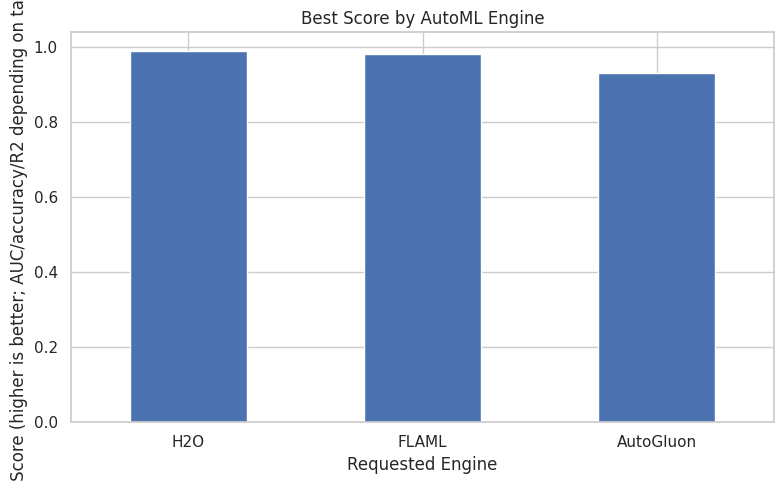

In [7]:
plot_df = comparison_df.dropna(subset=["Best Score"])
if not plot_df.empty:
    ax = plot_df["Best Score"].plot(kind="bar", color="#4C72B0", figsize=(8, 5))
    ax.set_title("Best Score by AutoML Engine")
    ax.set_ylabel("Best Score (higher is better; AUC/accuracy/R2 depending on task type)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No successful engine runs to plot -- check the 'Error' column above.")


## 7. Inspect a single engine's full leaderboard

`all_results` holds every candidate model each engine tried (not just the winner), so you can see how close the runner-up models were, or (for H2O/AutoGluon) inspect the underlying stacked-ensemble leaderboard.


In [8]:
# Change this to "H2O" or "AutoGluon" to inspect a different engine's leaderboard
inspect_label = "FLAML"

inspect_status = engine_statuses.get(inspect_label)
if inspect_status and inspect_status.get("status") == "completed":
    all_results = inspect_status["results"]["all_results"]
    leaderboard_df = pd.DataFrame(all_results).T
    print(f"--- {inspect_label} full leaderboard ---")
    display(leaderboard_df)
else:
    print(f"{inspect_label} run did not complete successfully; nothing to show.")


--- FLAML full leaderboard ---


,model_name,metrics
lgbm,lgbm,{'loss': 0.01992228467452084}
rf,rf,{'loss': 0.11695575467060437}
xgboost,xgboost,{'loss': 0.21047165975332155}
extra_tree,extra_tree,{'loss': 0.03733851834577466}
xgb_limitdepth,xgb_limitdepth,{'loss': None}
sgd,sgd,{'loss': 0.11453471546161839}
lrl1,lrl1,{'loss': None}


## 8. Cleanup (optional)

The trained models stay registered in the backend's in-memory/model-dir store like any other Decisera model (usable via `/models/{model_id}/metrics`, `/models/predict`, etc.) until you remove them. `DELETE /api/v1/models/{model_id}` handles that properly: it drops the in-memory record, deletes the `.joblib` file, and (for the H2O run) also purges that run's full leaderboard from the H2O cluster's in-memory DKV store -- H2O keeps every candidate model resident, not just the leader, so skipping this step leaks JVM memory across repeated benchmark runs.


In [9]:
delete_after_run = True  # flip to True to remove the three benchmark models this notebook just created

if delete_after_run:
    for label, status in engine_statuses.items():
        model_id = status.get("model_id")
        if not model_id:
            continue
        resp = requests.delete(f"{API_BASE}/models/{model_id}", timeout=30)
        resp.raise_for_status()
        print(f"[{label}] deleted model_id={model_id}: {resp.json()['message']}")
else:
    print("Skipping cleanup (delete_after_run=False). Set it to True to delete the benchmark models above.")


[H2O] deleted model_id=model_be28f76d_target_92b7b4: Model model_be28f76d_target_92b7b4 deleted successfully
[FLAML] deleted model_id=model_be28f76d_target_809793: Model model_be28f76d_target_809793 deleted successfully
[AutoGluon] deleted model_id=model_be28f76d_target_2bd7c7: Model model_be28f76d_target_2bd7c7 deleted successfully
